# CP GENIE

In [1]:
!pip install -qU langchain
!pip install -qU langchain-google-genai
!pip install -qU langchain_google_vertexai
!pip install -qU langchain-huggingface
!pip install -qU langchain-qdrant
!pip install -qU langchain-community
!pip install -qU langchain-tavily
!pip install -qU langgraph
!pip install fastembed
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.7/437.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.6 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.4 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.18 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 67.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.8/131.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# import os
# from google.colab import userdata

# os.environ["GOOGLE_API_KEY"] = userdata.get('gemini_api_key')
# os.environ["LANGSMITH_API_KEY"] = userdata.get('langsmith_api_key')
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["QDRANT_API_KEY"] = userdata.get('qdrant_api_key')

In [2]:
import os
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

os.environ["GOOGLE_API_KEY"] = user_secrets.get_secret('gemini_api_key')
os.environ["LANGSMITH_API_KEY"] = user_secrets.get_secret('langsmith_api_key')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["QDRANT_API_KEY"] = user_secrets.get_secret('qdrant_api_key')
os.environ["TAVILY_API_KEY"] = user_secrets.get_secret("tavily_api_key")
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/cp-genie-eval/gen-lang-client-0538587318-139709ed5d52.json"

In [37]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-preview-04-17")

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings

model_kwargs = {'trust_remote_code': True}
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs=model_kwargs)

2025-05-09 15:26:16.480595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746804376.656734      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746804376.705248      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

In [4]:
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

rerank_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [5]:
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, SparseVectorParams, VectorParams

sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

danish.txt:   0%|          | 0.00/424 [00:00<?, ?B/s]

catalan.txt:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

bengali.txt:   0%|          | 0.00/5.44k [00:00<?, ?B/s]

arabic.txt:   0%|          | 0.00/6.35k [00:00<?, ?B/s]

...

spanish.txt:   0%|          | 0.00/2.18k [00:00<?, ?B/s]

portuguese.txt:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tajik.txt:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

swedish.txt:   0%|          | 0.00/559 [00:00<?, ?B/s]

turkish.txt:   0%|          | 0.00/260 [00:00<?, ?B/s]

In [8]:
# Set your Qdrant endpoint and API key
client = QdrantClient(
    url="https://47ac79b4-c844-45e1-9b94-84e446d9382f.us-west-2-0.aws.cloud.qdrant.io:6333",
    api_key=os.environ["QDRANT_API_KEY"],
)

In [9]:
qdrant = QdrantVectorStore(
    client=client,
    collection_name="cp-genie-2",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)

In [10]:
sys_prompt = """
"You are GIGI a helpful and friendly assistant designed to support staff, students, and teachers. You are polite, helpful, and supportive.
If you don't know the context of the question, you can retrieve from the tools calling.
"""

## Naive

In [32]:
k = 10

In [33]:
retriever = qdrant.as_retriever(search_type="similarity", k=k)

query = "ผศ.ดร.เกริก ภิรมย์โสภา ได้รางวัลอะไรบ้าง ช่วงไหน"
results = retriever.invoke(query)

for doc in results:
    # print(doc.metadata["title"])
    print(doc.page_content[:300])
    print("-" * 50)

ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา Tweet March 28, 2016 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา เป็นผู้ได้รับรางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558 ได้รับรางวัลระดับดีเด่น สา
--------------------------------------------------
ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย Tweet September 4, 2018 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย วัน อ
--------------------------------------------------
ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภาและทีม กับรางวัล BRONZE PRIZE Tweet December 4, 2017 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภาและทีม กับรางวัล BRONZE PRIZE (หุ่นยนต์แบบมีปฏิสัมพันธ์เพื่อการเรียนรู้เชิงรุก) ในงาน Seoul Internatio

In [34]:
context = ""
for idx, doc in enumerate(results):
    # title = doc.metadata["title"]
    content = doc.page_content

    sums_str = f"""Document {idx+1}
Content: {content}
      """
    context += sums_str + '\n'

input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:
"""

In [35]:
# print(input_text)

Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:
Document 1
Content: ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา Tweet March 28, 2016 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา เป็นผู้ได้รับรางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558 ได้รับรางวัลระดับดีเด่น สาขาวิทยาศาสตร์และเทคโนโลยี
      
Document 2
Content: ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย Tweet September 4, 2018 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย วัน อังคาร ที่ 4 กันยายน 2561 ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย รางวัลระดับนานาชาติและระ

In [38]:
response = llm.invoke(input_text)
print(response.content)

จากข้อมูลที่ให้มา ผศ.ดร.เกริก ภิรมย์โสภา ได้รับรางวัลดังนี้:

1.  รางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558 ระดับดีเด่น สาขาวิทยาศาสตร์และเทคโนโลยี เมื่อวันที่ 28 มีนาคม 2559
2.  รางวัล BRONZE PRIZE (ร่วมกับทีม) ในงาน Seoul International Innovation Fair 2017 เมื่อวันที่ 4 ธันวาคม 2560
3.  รางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย ระดับนานาชาติและระดับชาติประจำปี 2560 – 2561 เมื่อวันที่ 4 กันยายน 2561


### Reranker

In [13]:
reranker = CrossEncoderReranker(
    model = rerank_model,
    top_n = 10
)

retriever_reranked = ContextualCompressionRetriever(
    base_retriever=retriever,
    base_compressor=reranker
)

## Corrective RAG

In [181]:
### Generate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_vertexai import ChatVertexAI
from langchain_core.prompts import ChatPromptTemplate

# Prompt
rag_prompt = ChatPromptTemplate.from_template(
    """Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"""
)
# LLM
rag_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

# Post-processing
def format_docs(docs):
    return "\\n\\n".join(doc.page_content for doc in docs)
# Chain
rag_chain = rag_prompt | rag_llm | StrOutputParser()
print(rag_prompt.messages[0].prompt.template)

Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:
{context}

Question: {question}

Answer:


In [182]:
### Retrieval Evaluator
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_google_vertexai import ChatVertexAI

# Data model
class RetrievalEvaluator(BaseModel):
    """Classify retrieved documents based on how relevant it is to the user's question."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )
    
# LLM with function call
retrieval_evaluator_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")
structured_llm_evaluator = retrieval_evaluator_llm.with_structured_output(RetrievalEvaluator)

# Prompt
system = """You are a document retrieval evaluator that's responsible for checking the relevancy of a retrieved document to the user's question. \\n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \\n
    Output a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""

retrieval_evaluator_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \\n\\n {document} \\n\\n User question: {question}"),
    ]
)

retrieval_grader = retrieval_evaluator_prompt | structured_llm_evaluator

In [183]:
### Question Re-writer

# LLM
question_rewriter_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized \\n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \\n\\n {question} \\n Formulate an improved question. Answer only improved question that can be used by search tool",
        ),
    ]
)

question_rewriter = re_write_prompt | question_rewriter_llm | StrOutputParser()

In [184]:
### Search
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3)

In [185]:
from typing import List
from typing_extensions import TypedDict
class GraphState(TypedDict):
    """
    Represents the state of our graph.
    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [186]:
from langchain.schema import Document
def retrieve(state):
    """
    Retrieve documents
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]
    # Retrieval
    documents = retriever.invoke(question)
    # documents = retriever_reranked.invoke(question)
    return {"documents": documents, "question": question}

In [187]:
def generate(state):
    """
    Generate answer
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [188]:
def evaluate_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    if len(filtered_docs) / len(documents) <= 0.7:
        web_search = "Yes"
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

In [189]:
def transform_query(state):
    """
    Transform the query to produce a better question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

In [190]:
def web_search(state):
    """
    Web search based on the re-phrased question.
    Args:
        state (dict): The current graph state
    Returns:
        state (dict): Updates documents key with appended web results
    """
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]
    # Web search
    docs = web_search_tool.invoke({"query": question})
    # print(docs)
    web_results = "\\n".join([d["content"] for d in docs['results']])
    # web_results = 'Content from web search'
    web_results = Document(page_content=web_results)
    documents.append(web_results)
    return {"documents": documents, "question": question}

In [191]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.
    Args:
        state (dict): The current graph state
    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]
    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [192]:
from langgraph.graph import END, StateGraph, START
workflow = StateGraph(GraphState)
# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", evaluate_documents)  # evaluate documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search
# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)
# Compile
app = workflow.compile()

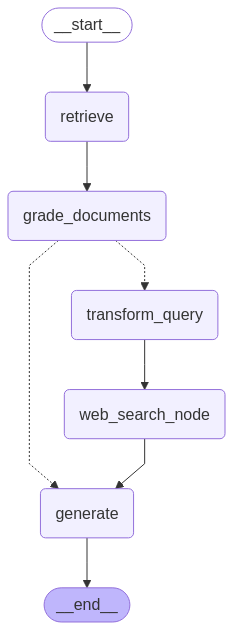

In [193]:
from IPython.display import Image, display
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [169]:
inputs = {"question": "วิศวกรรมคอมพิวเตอร์จุฬาฯ มีข้อดีอะไรบ้าง"}

In [ ]:
output = app.invoke(inputs)

In [138]:
output.keys()

dict_keys(['question', 'generation', 'web_search', 'documents'])

In [141]:
output

{'question': 'วิศวกรรมคอมพิวเตอร์ จุฬาฯ ดีไหม',
 'generation': 'จากข้อมูลที่ให้มา หลักสูตรวิศวกรรมคอมพิวเตอร์และเทคโนโลยีดิจิทัลที่จุฬาลงกรณ์มหาวิทยาลัยมีการจัดการเรียนการสอนโดยคณาจารย์คุณภาพ มีวัตถุประสงค์เพื่อผลิตบุคลากรจำนวนมากที่มีความรู้ความสามารถทั้งทางวิชาการและปฏิบัติงานจริงเพื่อตอบสนองความต้องการของภาคอุตสาหกรรมและทันต่อการเปลี่ยนแปลงเทคโนโลยี\n\nนอกจากนี้ยังมีการร่วมมือกับบริษัท เออาร์วี (ARV) เพื่อปรับปรุงหลักสูตรและพัฒนาทักษะของนิสิตให้ครอบคลุมทั้งฮาร์ดแวร์ ซอฟต์แวร์ ปัญญาประดิษฐ์ และเครือข่าย ให้ทันสมัยต่อตลาดแรงงาน โดยมีผู้เชี่ยวชาญจากอุตสาหกรรมให้คำแนะนำแก่นิสิตตลอดโครงการ',
 'web_search': 'Yes',
 'documents': [Document(metadata={'_id': '35eb3a2c-9356-43cf-9198-27f679adf566', '_collection_name': 'cp-genie-2'}, page_content='ซึ่งไม่เพียงพอต่อความต้องการของประเทศที่อยู่ในระดับหลายหมื่นคนต่อปีได้ การจัดการเรียนการสอนที่มีประสิทธิภาพ โดยคณาจารย์คุณภาพจากภาควิชาวิศวกรรมคอมพิวเตอร์ จุฬาลงกรณ์มหาวิทยาลัย ผ่านเทคโนโลยีการเรียนรู้ออนไลน์ที่สามารถขยายขนาดของห้องเรียนแบบดิจิทัลได้ 

In [101]:
from pprint import pprint
# Run
inputs = {"question": "ผศ.ดร.เกริก ภิรมย์โสภา ได้รางวัลอะไรบ้าง ช่วงไหน"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        pprint(value, indent=2, width=80, depth=None)
    pprint("\\n---\\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
{ 'documents': [ Document(metadata={'_id': '49105762-2c29-48d4-898d-0f50b3dfe451', '_collection_name': 'cp-genie-2'}, page_content='ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา Tweet March 28, 2016 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ ขอแสดงความยินดี ผศ.ดร.เกริก ภิรมย์โสภา เป็นผู้ได้รับรางวัลยกย่องเชิดชูเกียรติอาจารย์ด้านการเรียนการสอน กองทุนกาญจนาภิเษกเฉลิมพระเกียรติ ประจำปี 2558 ได้รับรางวัลระดับดีเด่น สาขาวิทยาศาสตร์และเทคโนโลยี'),
                 Document(metadata={'_id': '3d1630b0-98f8-4959-ba02-5b84dc3be008', '_collection_name': 'cp-genie-2'}, page_content='ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย Tweet September 4, 2018 ความสำเร็จ ภาควิชาวิศวกรรมคอมพิวเตอร์ขอแสดงความยินดี กับ ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกียรติบุคลากรแห่งจุฬาลงกรณ์มหาวิทยาลัย วัน อังคาร ที่ 4 กันยายน 2561 ผศ.ดร.เกริก ภิรมย์โสภา รับรางวัลยกย่องเชิดชูเกีย

In [204]:
from pprint import pprint
# Run
inputs = {"question": "วิศวกรรมคอมพิวเตอร์จุฬาฯ มีข้อดีอะไรบ้าง"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        pprint(value, indent=2, width=80, depth=None)
    pprint("\\n---\\n")
# Final generation
pprint(value["generation"])

---RETRIEVE---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

"Node 'retrieve':"
{ 'documents': [ Document(metadata={'_id': '35eb3a2c-9356-43cf-9198-27f679adf566', '_collection_name': 'cp-genie-2'}, page_content='ซึ่งไม่เพียงพอต่อความต้องการของประเทศที่อยู่ในระดับหลายหมื่นคนต่อปีได้ การจัดการเรียนการสอนที่มีประสิทธิภาพ โดยคณาจารย์คุณภาพจากภาควิชาวิศวกรรมคอมพิวเตอร์ จุฬาลงกรณ์มหาวิทยาลัย ผ่านเทคโนโลยีการเรียนรู้ออนไลน์ที่สามารถขยายขนาดของห้องเรียนแบบดิจิทัลได้ และการฝึกประสบการณ์ภาคสนามให้กับนิสิตอย่างสม่ำเสมอจากภาคอุตสาหกรรม จะช่วยสร้างบัณฑิตจำนวนมากที่มีความรู้ความสามารถทั้งทางวิชาการและในการปฏิบัติงานจริงให้กับอุตสาหกรรมได้อย่างรวดเร็ว และตอบสนองได้ทันต่อการก้าวกระโดดของเทคโนโลยีในปัจจุบันได้ 2 วัตถุประสงค์ เพื่อผลิตบุคลากรที่มีคุณภาพในสาขาวิชาวิศวกรรมคอมพิวเตอร์และเทคโนโลยีดิจิทัลจำนวนมาก ที่สามารถปฏิบัติงานในภาคอุตสาหกรรมได้ และมีทักษะที่ทันสมัยต่อการเปลี่ยนแปลงด้านเทคโนโลยี 3. ผลสัมฤทธิ์ที่ต้องการให้เกิดขึ้นแก่ผู้เรียน คุณลักษณะบัณฑิตที่พึงประสงค์ของหลักสูตรวิศวกรรมศาสตรบัณฑิต สาขาวิชาวิศวกรรมคอมพิวเตอร์และเทคโนโลยีดิจิทัล มีดังนี้ 1. มีความ

## Evaluation

In [162]:
!pip install -q ragas

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.4/680.4 kB 20.3 MB/s eta 0:00:00


In [163]:
# import pandas as pd
from ragas import evaluate, EvaluationDataset

# pd.set_option('display.max_colwidth', None)

In [164]:
import json
with open('/kaggle/input/cp-genie-eval/test_questions.json', 'r') as f:
    questions = json.load(f)

In [165]:
# questions[:5]

In [166]:
from langchain_google_vertexai import ChatVertexAI

eval_llm = ChatVertexAI(model="gemini-2.5-flash-preview-04-17", project="gen-lang-client-0538587318")

### Naive Evaluation

In [32]:
dataset = []

for question in questions:
    query = question['question']

    # Retrieve relevant documents
    # results = retriever.invoke(query)
    results = retriever_reranked.invoke(query) # Reranked

    # Build context from retrieved docs
    context = ""
    for idx, doc in enumerate(results):
        title = doc.metadata.get("title", "")
        content = doc.page_content
        context += f"Document {idx+1}\nTitle: {title}\nContent: {content}\n\n"

    # Prepare input for LLM
    input_text = f"""Perform the Question/Answering task on the given context. If you do not know the answer, just answer that you do not know.
Also you dont need to state which document you retrieve from.
Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"""

    # Get answer from chatbot
    response = llm.invoke(input_text)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': [doc.page_content for doc in results],
        'response': response.content,
        'reference': question['ground_truth'],
    })

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [33]:
# dataset[:5]

In [34]:
eval_dataset = EvaluationDataset.from_list(dataset)

# print(eval_dataset)
# print(eval_dataset[0])

In [35]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)

print(result)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

{'answer_relevancy': 0.6967, 'context_precision': 0.6150, 'faithfulness': 0.8618, 'context_recall': 0.5447}


In [36]:
results_df = result.to_pandas()
results_df.head()

,user_input,retrieved_contexts,response,reference,answer_relevancy,context_precision,faithfulness,context_recall
0,อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเ...,[ภาควิชาวิศวกรรมคอมพิวเตอร์ คณะวิศวกรรมศาสตร์ ...,"Based on the context provided, I do not know w...","ศ.ดร.วิวัฒน์ วัฒนาวุฒิ, รศ.ดร.เกริก ภิรมย์โสภา...",0.000000,0.000000,1.0,0.235294
1,อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น,[Update: 2024-06-13 12:30:41 (generated by CPM...,จากข้อมูลที่ให้มา อาจารย์ที่จบการศึกษาจากประเท...,"ศ.ดร.บุญเสริม กิจศิริกุล, รศ.ดร.กุลธิดา โรจน์ว...",0.952000,1.000000,1.0,0.333333
2,อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusett...,[Sensors Virtual Tourism อ.ดร.สุธี เรืองวิเศษ ...,อาจารย์ที่จบการศึกษาจาก Massachusetts Institut...,"ผศ.ดร.เอกพล ช่วงสุวนิช, รศ.ดร.อติวงศ์ สุชาโต, ...",0.986447,0.916667,1.0,0.666667
3,อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ,[Update: 2024-06-13 12:30:41 (generated by CPM...,อาจารย์ที่จบการศึกษาจากประเทศอังกฤษ ได้แก่ ศ.ด...,"ศ.ดร.ประภาส จงสถิตย์วัฒนา, รศ.ดร.ทวิตีย์ เสนีว...",0.984563,1.000000,0.5,0.333333
4,อาจารย์ท่านใดที่มีความสนใจด้าน Artificial Inte...,[Transportation Systems; Artificial Intelligen...,อาจารย์ที่มีความสนใจด้าน Artificial Intelligen...,"ศ.ดร.บุญเสริม กิจศิริกุล, ศ.ดร.ประภาส จงสถิตย์...",0.936200,0.500000,1.0,0.076923


In [37]:
results_df.to_csv(f'm3_hybrid_reranked_c1000_k{k}_naive_evaluation.csv', index=False)

### Corrective Evaluation

In [ ]:
%%capture
dataset = []

for question in questions:
    inputs = {"question": question['question']}
    print(inputs)

    output = app.invoke(inputs)

    answer = output.get("generation")
    documents = output.get("documents", [])
    retrieved_context = [ d.page_content for d in documents ]

    print(answer)
    print(retrieved_context)

    # Append to dataset list
    dataset.append({
        'user_input': question['question'],
        'retrieved_contexts': retrieved_context,
        'response': answer,
        'reference': question['ground_truth'],
    })

In [195]:
eval_dataset = EvaluationDataset.from_list(dataset)

print(eval_dataset)
print(eval_dataset[0])

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response', 'reference'], len=50)
user_input='อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเตอร์จากจุฬาฯ' retrieved_contexts=['Update: 2024-06-13 12:30:41 (generated by CPMIS) คณาจารย์ รายนามคณาจารย์ รายละเอียด เว็บไซต์ อีเมล ศ.ดร. บุญเสริม กิจศิริกุล PROF.DR. BOONSERM KIJSIRIKUL D.Eng.(Electronic and Electrical Engineering Tokyo Institute of Technology, Japan) M.Eng.(Tokyo Institute of\\nผู้สนใจ. ประกาศรับสมัคร นิสิต ระดับบัณฑิตศึกษา ภาคต้น 2568 เปิดรับสมัครวันที่ 1 กุมภาพันธ์ 2568 ถึง วันที่ 9 พฤษภาคม 2568\\nหลักสูตรวิศวกรรมศาสตรบัณฑิต สาขาวิชาวิศวกรรมคอมพิวเตอร์'] reference_contexts=None response='จากข้อมูลที่ให้มา ไม่ได้ระบุว่าอาจารย์ท่านใดจบปริญญาตรีจากจุฬาฯ' multi_responses=None reference='ศ.ดร.วิวัฒน์ วัฒนาวุฒิ, รศ.ดร.เกริก ภิรมย์โสภา, รศ.ดร.ดวงดาว วิชาดากุล, รศ.ดร.ธนารัตน์ ชลิดาพงศ์, รศ.ดร.นัทที นิภานันท์, รศ.ดร.วีระ เหมืองสิน, ผศ.ดร.ณรงค์เดช กีรติพรานนท์, ผศ.ดร.ณัฐวุฒิ หนูไพโรจน์, ผศ.ดร.เนื่องวงศ์ ทวยเจริญ, ผศ.ดร.

In [196]:
result = evaluate(eval_dataset, llm=eval_llm, embeddings=embeddings)

print(result)

Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

{'answer_relevancy': 0.6245, 'context_precision': 0.6550, 'faithfulness': 0.8466, 'context_recall': 0.5469}


In [197]:
results_df = result.to_pandas()
results_df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,user_input,retrieved_contexts,response,reference,answer_relevancy,context_precision,faithfulness,context_recall
0,อาจารย์ท่านใดบ้างที่จบปริญญาตรีวิศวกรรมคอมพิวเ...,[Update: 2024-06-13 12:30:41 (generated by CPM...,จากข้อมูลที่ให้มา ไม่ได้ระบุว่าอาจารย์ท่านใดจบ...,"ศ.ดร.วิวัฒน์ วัฒนาวุฒิ, รศ.ดร.เกริก ภิรมย์โสภา...",0.000000,0.000000,1.000000,0.000000
1,อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศญี่ปุ่น,[Update: 2024-06-13 12:30:41 (generated by CPM...,ตามข้อมูลในบริบท อาจารย์ไทยที่จบการศึกษาจากประ...,"ศ.ดร.บุญเสริม กิจศิริกุล, รศ.ดร.กุลธิดา โรจน์ว...",0.944280,1.000000,0.000000,0.333333
2,อาจารย์ท่านใดบ้างที่จบการศึกษาจาก Massachusett...,[Sensors Virtual Tourism อ.ดร.สุธี เรืองวิเศษ ...,จากข้อมูลที่ให้มา อาจารย์ที่จบการศึกษาจาก Mass...,"ผศ.ดร.เอกพล ช่วงสุวนิช, รศ.ดร.อติวงศ์ สุชาโต, ...",0.967077,1.000000,1.000000,0.666667
3,อาจารย์ท่านใดบ้างที่จบการศึกษาจากประเทศอังกฤษ,[Update: 2024-06-13 12:30:41 (generated by CPM...,จากบริบทที่ให้มา รายชื่อคณาจารย์ที่จบจากประเทศ...,"ศ.ดร.ประภาส จงสถิตย์วัฒนา, รศ.ดร.ทวิตีย์ เสนีว...",0.892337,1.000000,1.000000,0.333333
4,อาจารย์ท่านใดที่มีความสนใจด้าน Artificial Inte...,[Transportation Systems; Artificial Intelligen...,ตามข้อมูลในเอกสาร รายชื่ออาจารย์ที่มีความเชี่ย...,"ศ.ดร.บุญเสริม กิจศิริกุล, ศ.ดร.ประภาส จงสถิตย์...",0.777678,0.500000,1.000000,0.076923
5,อาจารย์ท่านใดมีความสนใจด้าน Quantum Computing,[ขอนแก่น) Interests: Object-Oriented Technolog...,"Based on the context, the professors specializ...",อ.ดร.กมลลักษณ์ สุขเสน,0.788706,1.000000,1.000000,1.000000
6,อาจารย์ท่านใดมีความสนใจด้าน Image Processing ห...,[Update: 2025-02-27 14:39:35 (generated by CPM...,อาจารย์ที่มีความสนใจด้าน Image Processing หรือ...,"รศ.ดร.พิษณุ คนองชัยยศ, รศ.ดร.ธนารัตน์ ชลิดาพงศ...",0.960073,0.916667,0.750000,0.666667
7,อาจารย์ท่านใดมีความสนใจเกี่ยวกับด้าน Software ...,[WANCHAI RIVEPIBOON Ph.D. (Grenoble 1) Interes...,"Based on the context, here are the research in...","รศ.ดร.ธาราทิพย์ สุวรรณศาสตร์, รศ.นครทิพย์ พร้อ...",0.853886,0.000000,1.000000,0.000000
8,อาจารย์ท่านใดมีความสนใจในด้าน Game Development,[PIZZANU KANONGCHAIYOS Ph.D.(Information Scien...,จากข้อมูลที่ให้มา อาจารย์ที่สอนหรือวิจัยด้าน G...,รศ.ดร.วิษณุ โคตรจรัส,0.873616,1.000000,0.750000,1.000000
9,อาจารย์ท่านใดบ้างที่มีความสนใจในด้าน Computer ...,[Transportation Systems; Artificial Intelligen...,อาจารย์ผู้เชี่ยวชาญด้าน Computer Network จากข้...,"รศ.ดร.กุลธิดา โรจน์วิบูลย์ชัย, รศ.ดร.ณัฐวุฒิ ห...",0.799925,0.000000,0.833333,0.200000


In [198]:
results_df.to_csv('corrective_rag_reranked_evaluation.csv', index=False)

### Evalation Visualize

In [199]:
import plotly.express as px
import ast

In [200]:
str(result)

"{'answer_relevancy': 0.6245, 'context_precision': 0.6550, 'faithfulness': 0.8466, 'context_recall': 0.5469}"

In [201]:
data = ast.literal_eval(str(result))

# Extract metrics and scores
metrics = list(data.keys())
scores = list(data.values())

# Create a bar chart using Plotly
fig = px.bar(x=metrics, y=scores, labels={'x': 'Metric', 'y': 'Score'}, title='Metric Scores')
fig.update_layout(yaxis_range=[0, 1])

# Display the plot
fig.show()